In [44]:
import numpy as np
import matplotlib.pyplot as plt


def paper_jump_rate_coefficients(
    *,
    delta: float,
    Gamma: float,
    omega_over_omega_c: float,
    N: int,
) -> dict:
    """
    Compute the small-detuning paper coefficients for

        l_eff ≈ C + A S_z

    where

        C = (delta / Gamma) tan(theta_tilde)
        A = 2 delta sin(theta_tilde) / (N Gamma cos(theta_tilde)^3)

    with

        sin(theta_tilde) = Omega / Omega_c.
    """

    if Gamma <= 0:
        raise ValueError("Gamma must be positive.")
    if N <= 0:
        raise ValueError("N must be positive.")

    sin_theta = float(omega_over_omega_c)

    if abs(sin_theta) >= 1.0:
        raise ValueError(
            f"Invalid approximation: |Omega/Omega_c| = {abs(sin_theta):.6g} >= 1. "
            "The small-detuning spin-polarized approximation assumes Omega < Omega_c."
        )

    cos_theta = np.sqrt(1.0 - sin_theta**2)
    tan_theta = sin_theta / cos_theta

    C = (delta / Gamma) * tan_theta

    A = (
        2.0
        * delta
        * sin_theta
        / (N * Gamma * cos_theta**3)
    )

    R0 = Gamma * abs(C) ** 2
    B = Gamma * abs(A) ** 2

    return {
        "sin_theta": sin_theta,
        "cos_theta": cos_theta,
        "tan_theta": tan_theta,
        "C": C,
        "A": A,
        "R0": R0,
        "B": B,
    }


def uniform_sector_variance(half_width: int) -> float:
    """
    Variance of N_J for equal weights over

        N_J = N/2 - dN, ..., N/2, ..., N/2 + dN

    where half_width = dN.
    """

    if half_width < 0:
        raise ValueError("half_width must be >= 0.")

    dN = half_width
    return dN * (dN + 1) / 3.0


def plot_paper_jump_count_vs_half_width(
    *,
    delta: float,
    Gamma: float,
    N: int,
    omega_over_omega_c: float,
    max_half_width: int,
    ax=None,
    label: str | None = None,
):
    """
    Plot the paper approximate raw jump count vs number of included N_J sectors.

    Uses

        Count_approx(dN) = T * (R0 + B Var(N_J))

    with equal/square sector weights, so

        Var(N_J) = dN(dN+1)/3.

    The x-axis is number of sectors:

        n_sectors = 2 dN + 1.

    Returns
    -------
    dict containing:
        half_widths
        n_sectors
        var_Nj
        jump_count
        coeffs
        fig
        ax
    """

    if max_half_width < 0:
        raise ValueError("max_half_width must be >= 0.")

    coeffs = paper_jump_rate_coefficients(
        delta=delta,
        Gamma=Gamma,
        omega_over_omega_c=omega_over_omega_c,
        N=N,
    )
    print(f"A: {coeffs['A']}")
    print(f"B: {coeffs['B']}")

    R0 = coeffs["R0"]
    B = coeffs["B"]

    half_widths = np.arange(max_half_width + 1, dtype=int)
    n_sectors = 2 * half_widths + 1

    var_Nj = np.array(
        [uniform_sector_variance(int(dN)) for dN in half_widths],
        dtype=float,
    )

    simulation_time = 10.0
    jump_count = simulation_time * (R0 + B * var_Nj)

    if ax is None:
        fig, ax = plt.subplots(figsize=(7, 4))
    else:
        fig = ax.figure

    if label is None:
        label = (
            rf"$\delta={delta}$, $\Gamma={Gamma}$, "
            rf"$\Omega/\Omega_c={omega_over_omega_c}$"
        )

    ax.plot(n_sectors, jump_count, label=label)
    ax.set_xlabel(r"Number of included $N_J$ sectors, $2dN+1$")
    ax.set_ylabel(r"Approx. jump count")
    ax.set_title(r"Paper approximate jump count vs sector number")
    #ax.set_ylim(0, 1.1 * max(jump_count))
    ax.grid(True, alpha=0.3)
    ax.legend()

    return {
        "half_widths": half_widths,
        "n_sectors": n_sectors,
        "var_Nj": var_Nj,
        "jump_count": jump_count,
        "coeffs": coeffs,
        "fig": fig,
        "ax": ax,
    }

A: 0.012989160133094787
B: 0.00016871828096317898


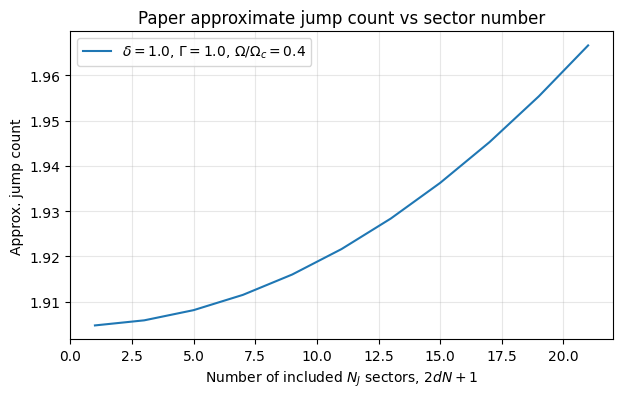

In [45]:
delta = 1.0
Gamma = 1.0

out = plot_paper_jump_count_vs_half_width(
    delta=delta,
    Gamma=Gamma,
    N=80,
    omega_over_omega_c=0.4,
    max_half_width=10,
)

plt.show()